# PyPSA Übung 03

### CO<sub>2</sub>-Budget für den deutschen Strommarkt

Im Auftrag des Umweltbundesamtes sollen Sie ein Szenario untersuchen, in dem Deutschland die **CO<sub>2</sub>-Emission** für die Stromproduktion um **30 % reduziert**. Dafür untersuchen Sie beispielhaft Tage, wie etwa am 9. April 2024. Wie viele Tonnen CO<sub>2</sub> wurden emittiert?

Betrachten Sie dabei die Unterschiede am Strommarkt mit und ohne CO<sub>2</sub>-Limitierung. Wie viele Tonnen CO<sub>2</sub> werden eingespart und wie wirkt sich das CO<sub>2</sub>-Limit auf die Preise aus.

Neben einem CO<sub>2</sub> Preis von **40 €/t_CO<sub>2</sub>** stehen folgende Parameter zur Verfügung: 

| Technologie | Installierte Leistung [MW_el] | Effizienz [MW_el/MW_PE] | Kosten [€/MWh_PE] | CO<sub>2</sub> [t/MWh_PE] |
| ----------- | ----------------------------: | ----------------------: | ----------------: | -------------: |
| Wind        |                        63400 |                       – |                 – |              – |
| PV          |                        92400 |                       – |                 – |              – |
| Steinkohle  |                        15600 |                    0.39 |                9 |          0.338 |
| Braunkohle  |                        15100 |                    0.36 |                 2 |          0.407 |
| Gas         |                        35600 |                    0.52 |                25 |          0.202 |





Importieren Sie die Pandas und PyPSA Bibiliothek.

In [1]:
import pypsa
import pandas as pd

Legen Sie die gegebenen Parameter an. Berechnen Sie die fehlenden Kosten (inkl. CO2 und passend für marginal_cost der Generatoren) <br>Tipp: Carrier erwarten die Emission bezogen auf die Primär Energie, Generatoren erwarten die marginal cost bezogen auf den elektrischen Output des Generators. <br> https://docs.pypsa.org/latest/user-guide/components/generators/ <br> https://docs.pypsa.org/latest/user-guide/components/carriers/

In [2]:
co2_limit_relativ = 0.7     # ggf. anhand der unlimitierten Emmisionen eine prozentuale Constraint setzten...

cap_wind = 63400        # MW_el
cap_pv = 92400          # MW_el
cap_hard_coal = 15100   # MW_el
cap_lignite = 15600     # MW_el
cap_gas = 35600         # MW_el

eff_hard_coal = 0.39    # MWh_el / MWh_PrimaryEnergy
eff_lignite = 0.36      # MWh_el / MWh_PE
eff_gas = 0.52          # MWh_el / MWh_PE

co2_hard_coal = 0.338          # t/MWh_PE
co2_lignite = 0.407            # t/MWh_PE
co2_gas = 0.202                # t/MWh_PE

#CO2-Kosten
co2_price       =    40        # €/t_CO2   

cost_hard_coal = 9             # €/MWh_PE  
cost_lignite = 2               # €/MWh_PE
cost_gas = 25                  # €/MWh_PE


# Kosten Primärenergie inkl. CO2 Zertifikate
cost_hard_coal += co2_hard_coal * co2_price
cost_lignite += co2_lignite * co2_price
cost_gas += co2_gas * co2_price

# Kosten für MWh_el
cost_hard_coal /= eff_hard_coal
cost_lignite /= eff_lignite
cost_gas /= eff_gas

print('Steinkohle: \t', round(cost_hard_coal,2), '€/MWh_el')
print('Braunkohle: \t', round(cost_lignite,2), '€/MWh_el')
print('Erdgas: \t', round(cost_gas,2), '€/MWh_el')

Steinkohle: 	 57.74 €/MWh_el
Braunkohle: 	 50.78 €/MWh_el
Erdgas: 	 63.62 €/MWh_el


Lesen Sie die beigefügte csv-Datei als DataFrame ein.

In [3]:
df_data = pd.read_csv('data_PyPSA_3.csv', index_col='Datum')
df_data

,Netzlast [MW],Windpotential [MW],Solarpotential [MW]
Datum,,,
2024-04-09 00:00,43559.3,13318.6,0.0
2024-04-09 01:00,42094.8,13861.9,0.0
2024-04-09 02:00,41395.0,14064.5,0.0
2024-04-09 03:00,42502.3,13227.3,0.0
2024-04-09 04:00,43580.5,13109.1,0.0
2024-04-09 05:00,47219.3,14446.2,0.0
2024-04-09 06:00,55208.5,16091.7,121.3
2024-04-09 07:00,59665.8,17332.3,2388.7
2024-04-09 08:00,62712.5,16673.8,7001.4


Erstellen Sie das PyPSA Netzwerk und die Komponenten 
<br>Tipp: Erzeugen Sie die Carrier vor den Generatoren, auf diese wird beim Erstellen der Generatoren mit dem Attribut ```carrier='name_des_carriers'``` verwiesen.

In [4]:
# PyPSA Netzwerk & Snapshots
network = pypsa.Network()
network.set_snapshots(df_data.index)

# Carrier
network.add('Carrier', name = 'Braunkohle', co2_emissions = co2_lignite)
network.add('Carrier', name = 'Steinkohle', co2_emissions = co2_hard_coal)
network.add('Carrier', name = 'Gas', co2_emissions = co2_gas)
network.add('Carrier', name = 'PV', co2_emissions = 0)
network.add('Carrier', name = 'Wind', co2_emissions = 0)

# Bus
network.add('Bus', name = 'DE_LU')

# Load
network.add('Load', name = 'Verbrauch_DE_LU', bus = 'DE_LU', p_set = df_data['Netzlast [MW]'])

# Generatoren
network.add('Generator', name = 'Windkraftwerke', bus = 'DE_LU', carrier = 'Wind', p_nom = cap_wind, p_max_pu = df_data['Windpotential [MW]']/cap_wind)
network.add('Generator', name = 'PV-Kraftwerke', bus = 'DE_LU', carrier = 'PV', p_nom = cap_pv, p_max_pu = df_data['Solarpotential [MW]']/cap_pv)
network.add('Generator', name = 'BK-Kraftwerke', bus = 'DE_LU', carrier = 'Braunkohle', p_nom = cap_lignite, efficiency = eff_lignite, 
            marginal_cost = cost_lignite)
network.add('Generator', name = 'SK-Kraftwerke', bus = 'DE_LU', carrier = 'Steinkohle', p_nom = cap_hard_coal, efficiency = eff_hard_coal, 
            marginal_cost = cost_hard_coal)
network.add('Generator', name = 'Gas-Kraftwerke', bus = 'DE_LU', carrier = 'Gas', p_nom = cap_gas, efficiency = eff_gas, 
            marginal_cost = cost_gas)


Bevor Sie das Modell berechnen, kopieren Sie das Netzwerk (```netzwerk_co2_limit = network.copy()```). In dem neuen Netzwerk können sie später die CO2 Emission einschränken.

In [5]:
netzwerk_co2_limit = network.copy()

Führen Sie nun die Optimierung des ersten Netzwerks aus und begutachten Sie die Ergebnisse ohne CO2 Limit. Welche Generatoren werden wann und wie viel eingesetzt? (Tipp: ```network.beispiel_ergebnis.plot.bar(stacked=True)``` bietet hier eine gute Übersicht)

In [6]:
network.optimize(solver_name = 'gurobi')

C:\Users\PC\AppData\Local\Temp\ipykernel_17528\4088711822.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name = 'gurobi')
Index(['DE_LU'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io: Writing time: 0.14s


Restricted license - for non-production use only - expires 2026-11-23


INFO:gurobipy:Restricted license - for non-production use only - expires 2026-11-23


Read LP format model from file C:\Users\PC\AppData\Local\Temp\linopy-problem-u_tyc1tv.lp


INFO:gurobipy:Read LP format model from file C:\Users\PC\AppData\Local\Temp\linopy-problem-u_tyc1tv.lp


...

Solved in 15 iterations and 0.04 seconds (0.00 work units)


INFO:gurobipy:Solved in 15 iterations and 0.04 seconds (0.00 work units)


Optimal objective  3.799649952e+07


INFO:gurobipy:Optimal objective  3.799649952e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 120 primals, 264 duals
Objective: 3.80e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

In [7]:
network.statistics()

Optimal Capacity  Installed Capacity    Supply  \
Generator Braunkohle           15600.0             15600.0  374400.0   
          Gas                  35600.0             35600.0   41075.6   
          PV                   92400.0             92400.0  145797.0   
          Steinkohle           15100.0             15100.0  283533.8   
          Wind                 63400.0             63400.0  508540.7   
Load      -                        0.0                 0.0       0.0   

                      Withdrawal  Energy Balance Transmission  \
Generator Braunkohle         0.0        374400.0          0.0   
          Gas                0.0         41075.6          0.0   
          PV                 0.0        145797.0          0.0   
          Steinkohle         0.0        283533.8          0.0   
          Wind               0.0        508540.7          0.0   
Load      -            1353347.1      -1353347.1          0.0   

                      Capacity Factor  Curtailment  Capital Expenditure  \
Generator Braunkohle         1.000000          0.0                  0.0   
          Gas                0.048075     813324.4                  0.0   
          PV                 0.065745          0.0                  0.0   
          Steinkohle         0.782378      78866.2                  0.0   
          Wind               0.334214          0.0                  0.0   
Load      -                       NaN          0.0                  0.0   

                      Operational Expenditure       Revenue  Market Value  
Generator Braunkohle             1.901120e+07  2.244360e+07     59.945513  
          Gas                    2.613040e+06  2.613040e+06     63.615385  
          PV                     0.000000e+00  8.665532e+06     59.435600  
          Steinkohle             1.637226e+07  1.717024e+07     60.557988  
          Wind                   0.000000e+00  3.041440e+07     59.807216  
Load      -                      0.000000e+00 -8.130681e+07           NaN

<Axes: xlabel='snapshot'>

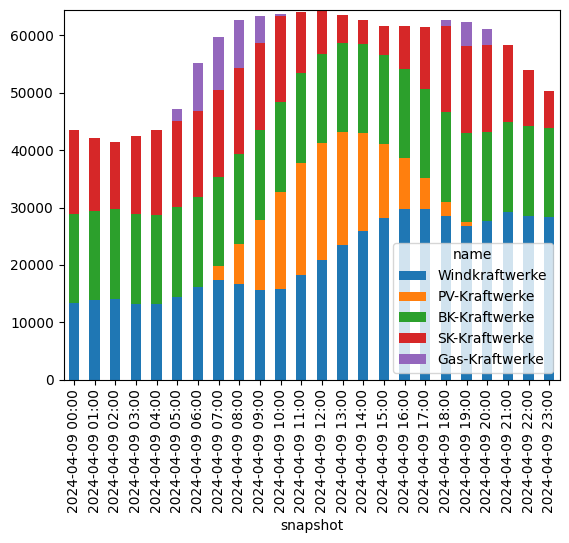

In [8]:
network.generators_t.p.plot.bar(stacked=True)


Wie fallen die CO2 Emissionen der fossilen Generatoren im Basisfalls aus?

In [9]:
co2_emissions = 0

for gen_name, gen in network.generators.iterrows():
    carrier = network.carriers.loc[gen.carrier]
    p = network.generators_t.p[gen_name]
    efficiency = gen.efficiency
    co2_emissions += (p / efficiency * carrier.co2_emissions).sum()

co2_emissions

684965.5841025641

#### CO2 Limit

Fügen Sie dem zweiten Netzwerk (Kopie) eine globale Constraint hinzu und beschänken Sie somit die CO2 Emission auf 70 % des Basisfalls. Optimieren Sie im Anschluss das Netzwerk und bewerten Sie die neuen Ergebnisse (Generatoren Dispatch und CO2 Emission).

In [10]:
netzwerk_co2_limit.add('GlobalConstraint', name = 'co2-limit', carrier_attribute = 'co2_emissions', sense = '<=', 
                       constant = co2_emissions*co2_limit_relativ, overwrite=True)

In [11]:
netzwerk_co2_limit.optimize(solver_name='gurobi')

C:\Users\PC\AppData\Local\Temp\ipykernel_17528\2603357934.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  netzwerk_co2_limit.optimize(solver_name='gurobi')
Index(['DE_LU'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io: Writing time: 0.03s


Restricted license - for non-production use only - expires 2026-11-23


INFO:gurobipy:Restricted license - for non-production use only - expires 2026-11-23


Read LP format model from file C:\Users\PC\AppData\Local\Temp\linopy-problem-z7wrn031.lp


INFO:gurobipy:Read LP format model from file C:\Users\PC\AppData\Local\Temp\linopy-problem-z7wrn031.lp


...

Solved in 35 iterations and 0.02 seconds (0.00 work units)


INFO:gurobipy:Solved in 35 iterations and 0.02 seconds (0.00 work units)


Optimal objective  4.087060426e+07


INFO:gurobipy:Optimal objective  4.087060426e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 120 primals, 265 duals
Objective: 4.09e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

<Axes: xlabel='snapshot'>

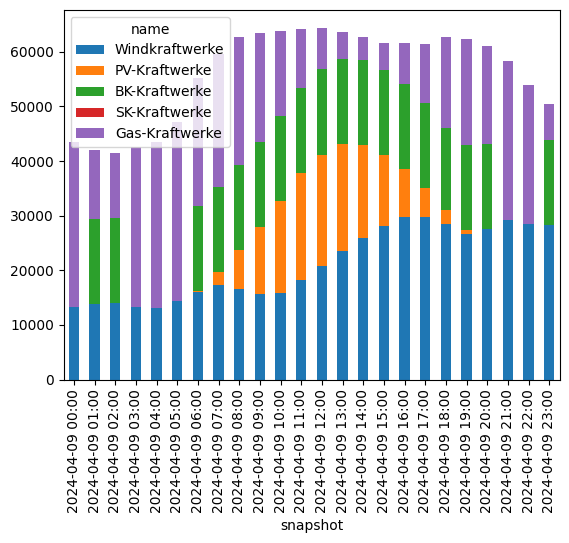

In [12]:
netzwerk_co2_limit.generators_t.p.plot.bar(stacked=True)

In [13]:
limit_co2_emissions = 0
for gen_name, gen in netzwerk_co2_limit.generators.iterrows():
    carrier = netzwerk_co2_limit.carriers.loc[gen.carrier]
    p = netzwerk_co2_limit.generators_t.p[gen_name]
    efficiency = gen.efficiency
    limit_co2_emissions += (p / efficiency * carrier.co2_emissions).sum()
limit_co2_emissions

479475.9088717947

Vergleichen Sie die Gesamtkosten der beiden Varianten sowie die jeweiligen Schattenpreise (marginal_price) der Energiebilanz der einzelnen Stunden. <br>(Was kostet es, wenn am Bus eine weitere MWh Energie bereitgestellt werden muss?) <br>Tipp: https://docs.pypsa.org/latest/user-guide/components/buses/

Woran könnte es liegen, dass der Schattenpreis einer weiteren MWh im Falle der CO2-Limitierung nicht dem maginal cost des notwendigen Generators entspricht?

In [14]:
print("Kosten ohne CO2-Limit:", round(network.objective * 1e-6, 2), "Millionen €")
print("Kosten mit CO2-Limit:", round(netzwerk_co2_limit.objective * 1e-6, 2), "Millionen €")


Kosten ohne CO2-Limit: 38.0 Millionen €
Kosten mit CO2-Limit: 40.87 Millionen €


In [15]:
market_price = pd.DataFrame({
    "Ohne Limit": network.buses_t.marginal_price["DE_LU"],
    "Mit Limit": netzwerk_co2_limit.buses_t.marginal_price["DE_LU"],
})

<Axes: title={'center': 'Marginal Price DE_LU'}, xlabel='snapshot', ylabel='€/MWh'>

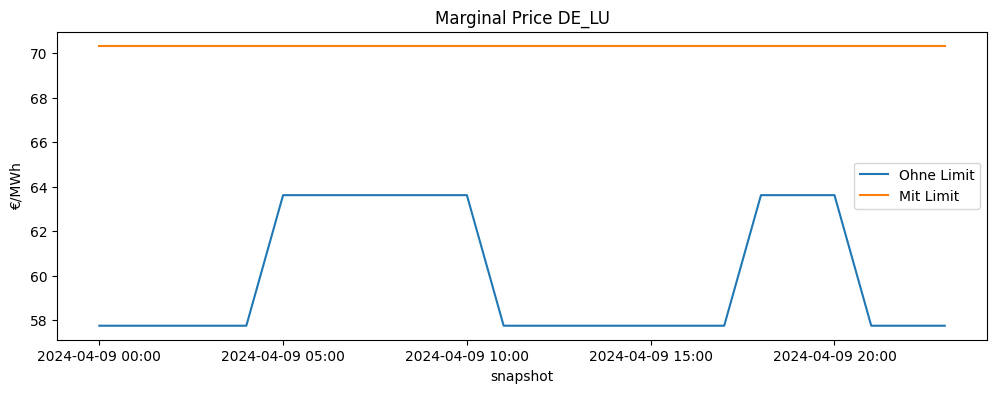

In [16]:
market_price.plot(figsize=(12, 4), ylabel="€/MWh", title="Marginal Price DE_LU")


Wie groß fallen die Schattenpreise der CO2-Constraint aus? Wie viel Geld kann durch die Emission einer zusätzlichen Tonne CO2 eingespart werden bzw. was würde es kosten eine Tonne CO2 weniger zu emittieren?
Tipp: https://docs.pypsa.org/latest/user-guide/components/global-constraints/

In [17]:
netzwerk_co2_limit.global_constraints.at['co2-limit', "mu"]

-17.299164987042907

In [18]:
#Differenzkosten
(netzwerk_co2_limit.objective -network.objective)/(co2_emissions - limit_co2_emissions)

13.986613850575818

#### Quellen:


https://energy-charts.info/charts/installed_power/chart.htm?l=de&c=DE&year=2024

- PV: 92.4 GW
- Wind Onshore: 63.6 GW
- Erdgas: 35.6 GW
- Braunkohle: 15.1 GW
- Steinkohle: 15.6 GW

https://www.umweltbundesamt.de/system/files/medien/11850/publikationen/2026-03/16_2026_CC.pdf

- Erdgas: 202 g/kWh 51%
- Steinkohle: 338 g/kWh 39%
- Braunkohle: 407 g/kWh 36%


https://github.com/PyPSA/technology-data/blob/master/inputs/Fraunhofer_ISE_energy_prices.csv
(Werte angepasst!)

- Erdgas: 23 €/MWh
- Steinkohle: 13 €/MWh
- Braunkohle: 2 €/MWh

